# Finite Source Effects 

This notebook creates illustrations of the effects of finite source radii during microlensing events. 

It is based on software written by Y. Tsapras and PyLIMA.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tqdm import tqdm
from pyLIMA.models import FSPL_model
from pyLIMA.outputs import pyLIMA_plots
from pyLIMA.simulations import simulator
from pyLIMA.toolbox import brightness_transformation
from pyLIMA import event

In [12]:
# Parameters of the microlensing event
I0 = 1.0
umin = 0.0
tau = 30.0
tmax = 15.0

In [81]:
def plot_lens_plane_images(umin, plot_file):

    # Source radii and angles
    radii = np.linspace(0.01, 0.1, 10)  # fewer radii for clarity
    angles = np.linspace(0, 2 * np.pi, 500)

    fig, ax1 = plt.subplots(1, 1, figsize=(12, 5))
    fig.subplots_adjust(left=0.08, right=0.95, bottom=0.15, top=0.92, wspace=0.05)

    # Plot the source position invisibly; this creates the right size of marker in the legend 
    ax1.plot(0.0, 0.0, '.', color='#fc3d21', markersize=8, alpha=1.0, label='Source')
    
    # Plot the lens 
    ax1.plot(0, 0, 'ko', markersize=5, label='Lens')
    
    # Plot the point of closest approach
    point = 45 / 15.0 - 3

    added_source = False
    for rs in radii:
        xs = rs * np.cos(angles) + point
        ys = rs * np.sin(angles) + umin
    
        beta = np.sqrt(xs**2 + ys**2)
        phi = np.arctan2(xs, ys)
    
        theta_p = beta / 2 + np.sqrt((beta / 2)**2 + 1)
        theta_m = beta / 2 - np.sqrt((beta / 2)**2 + 1)
    
        # Major image
        ximp, yimp = theta_p * np.sin(phi), theta_p * np.cos(phi)
        # Minor image
        ximm, yimm = theta_m * np.sin(phi), theta_m * np.cos(phi)
    
        ax1.plot(ximp, yimp, 'y.', markersize=1, alpha=0.5)
        ax1.plot(ximm, yimm, 'y.', markersize=1, alpha=0.5)
    
        # Plot the source location
        if not added_source:
            ax1.plot(xs, ys, '.', color='#fc3d21', markersize=1, alpha=0.2)
            added_source = True
        else:
            ax1.plot(xs, ys, '.', color='#fc3d21', markersize=1, alpha=0.2)
            
    # Plot the Einstein ring as a dashed circle
    ering = plt.Circle((0, 0), radius=1.0, color='gray', fill=False, alpha=1.0, ls='--', lw=2.0, label='Einstein ring')
    ax1.add_patch(ering)
    
    # Axis ranges and labels
    ax1.set(xlim=(-3.0, 3.0), ylim=(-3.0, 3.0), xlabel=r'$x/R_E$', ylabel=r'$y/R_E$')
    ax1.set_aspect('equal')
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Increase label sizes
    ax1.tick_params(axis='both', labelsize=12)
    ax1.xaxis.label.set_size(14)
    ax1.yaxis.label.set_size(14)

    ax1.legend()
    
    plt.tight_layout()
    plt.savefig(plot_file)


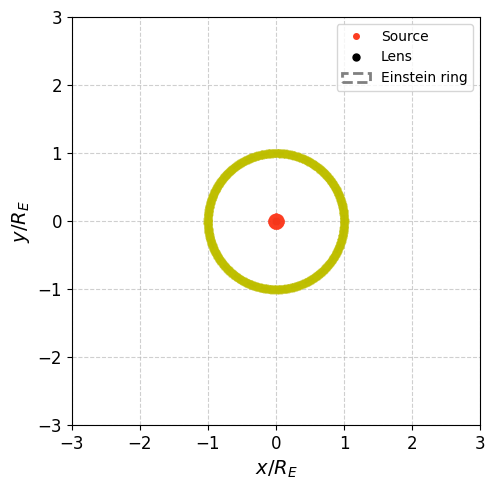

In [82]:
# Perfect alignment
umin = 0.0
plot_file = '/Users/rstreet/software/rges/notebooks/lens_perfect_alignment.png'
plot_lens_plane_images(umin, plot_file)

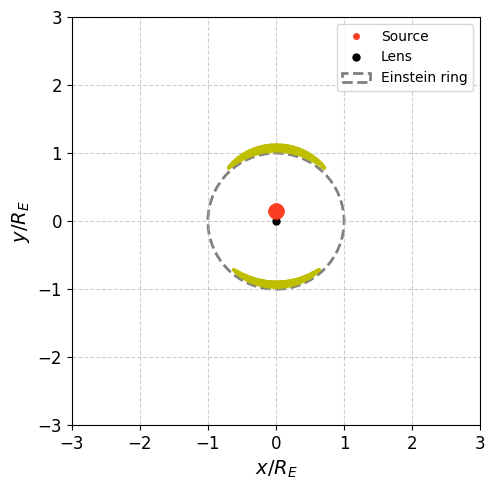

In [79]:
# Close to alignment 
umin = 0.15
plot_file = '/Users/rstreet/software/rges/notebooks/lens_close_alignment.png'
plot_lens_plane_images(umin, plot_file)

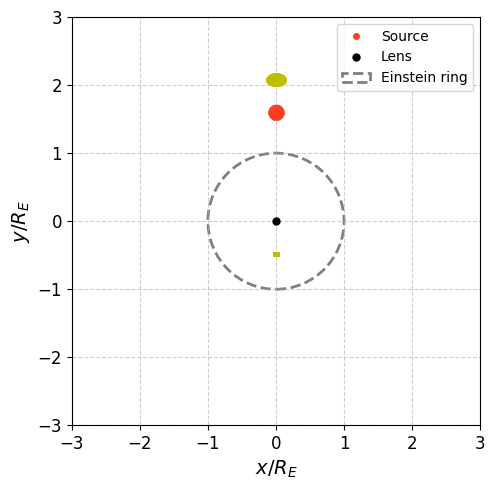

In [80]:
# Distant passage
umin = 1.6
plot_file = '/Users/rstreet/software/rges/notebooks/lens_distant_alignment.png'
plot_lens_plane_images(umin, plot_file)

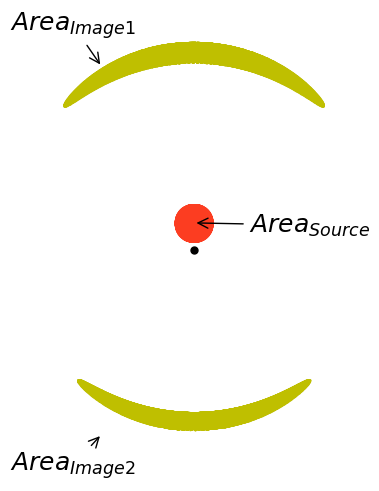

In [156]:
# Annotated version
umin = 0.15
plot_file = '/Users/rstreet/software/rges/notebooks/lensed_image_areas.png'

# Source radii and angles
radii = np.linspace(0.01, 0.1, 500)  # fewer radii for clarity
angles = np.linspace(0, 2 * np.pi, 500)

fig, ax1 = plt.subplots(1, 1, figsize=(5, 5))
fig.subplots_adjust(left=0.08, right=0.95, bottom=0.15, top=0.92, wspace=0.05)

# Plot the source position invisibly; this creates the right size of marker in the legend 
ax1.plot(0.0, 0.0, '.', color='#fc3d21', markersize=8, alpha=1.0, label='Source')

# Plot the lens 
ax1.plot(0, 0, 'ko', markersize=5, label='Lens')

# Plot the point of closest approach
point = 45 / 15.0 - 3

added_source = False
for rs in radii:
    xs = rs * np.cos(angles) + point
    ys = rs * np.sin(angles) + umin

    beta = np.sqrt(xs**2 + ys**2)
    phi = np.arctan2(xs, ys)

    theta_p = beta / 2 + np.sqrt((beta / 2)**2 + 1)
    theta_m = beta / 2 - np.sqrt((beta / 2)**2 + 1)

    # Major image
    ximp, yimp = theta_p * np.sin(phi), theta_p * np.cos(phi)
    # Minor image
    ximm, yimm = theta_m * np.sin(phi), theta_m * np.cos(phi)

    ax1.plot(ximp, yimp, 'y.', markersize=1, alpha=0.5)
    ax1.plot(ximm, yimm, 'y.', markersize=1, alpha=0.5)

    # Plot the source location
    if not added_source:
        ax1.plot(xs, ys, '.', color='#fc3d21', markersize=1, alpha=0.2)
        added_source = True
    else:
        ax1.plot(xs, ys, '.', color='#fc3d21', markersize=1, alpha=0.2)

# Annotations 
ax1.annotate('$Area_{Image 1}$', xy=(-0.5,1.0), xytext=(-1.0, 1.2), fontsize=18, arrowprops=dict(arrowstyle='->'))
ax1.annotate('$Area_{Image 2}$', xy=(-0.5,-1.0), xytext=(-1.0, -1.2), fontsize=18, arrowprops=dict(arrowstyle='->'))
ax1.annotate('$Area_{Source}$', xy=(0.0,0.15), xytext=(0.3, 0.1), fontsize=18, arrowprops=dict(arrowstyle='->'))

# Axis ranges and labels
plt.axis('off')
ax1.set_aspect('equal')


plt.tight_layout()
plt.savefig(plot_file)


## Plot of microlensing magnification with finite source effects

In [2]:
sim_event1 = event.Event(ra=270.0, dec=-30.0)
sim_event1.name = 'Simulated ulens'

In [3]:
# Simulate lightcurves 
lc1 = simulator.simulate_a_telescope(name='Tel1', time_start=2457000.0,
                                        time_end=2458100.0, sampling=10.0,
                                        location='Earth', camera_filter='I',
                                        uniform_sampling=True, astrometry=False)
sim_event1.telescopes.append(lc1)

sim_event1.check_event()

check_event  : Everything looks fine...


In [14]:
fspl = FSPL_model.FSPLmodel(sim_event1)
#pspl_params = simulator.simulate_microlensing_model_parameters(pspl)
fspl_params = [2457473.0689289137, 0.0001, 48.04376310086098, 0.5, 1626.8102917125927, 696780.40430339807]
pyLIMA_params = fspl.compute_pyLIMA_parameters(fspl_params)
print(pyLIMA_params)

OrderedDict({'t0': 2457473.0689289137, 'u0': 0.0001, 'tE': 48.04376310086098, 'rho': 0.5, 'fsource_Tel1': 1626.8102917125927, 'ftotal_Tel1': 696780.4043033981})


In [15]:
# Generate the lightcurve
simulator.simulate_lightcurve(fspl, pyLIMA_params)

In [16]:
# Compute the model lightcurve
tel = fspl.event.telescopes[0]
A = fspl.model_magnification(tel, pyLIMA_params)
fspl.derive_telescope_flux(tel, pyLIMA_params, A)
f_source = pyLIMA_params['fsource_' + tel.name]
f_blend = pyLIMA_params['fblend_' + tel.name]
print('Source flux = ' + str(f_source) + ', blend flux = ' + str(f_blend))

model_flux = f_source * A + f_blend
model_lc = brightness_transformation.ZERO_POINT - 2.5 * np.log10(model_flux)

Source flux = 1626.8102917125927, blend flux = 695153.5940116855


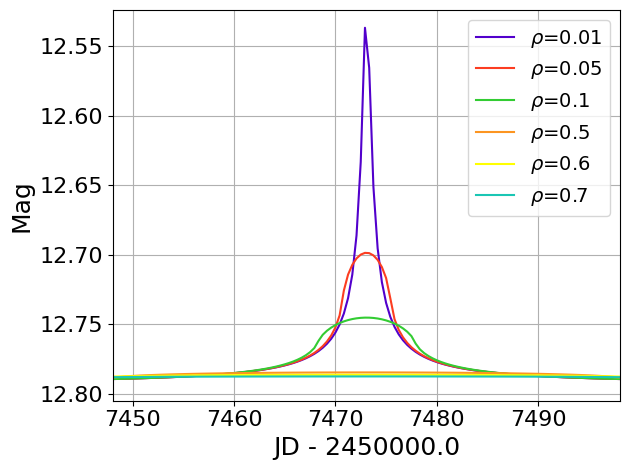

In [17]:
rho_range = np.array([0.01, 0.05, 0.1, 0.5, 0.6, 0.7])
plot_colors = ['#5200cc', '#fc3d21', '#33cc33', '#fc9521', '#ffff00', '#1ac6b4', '#2132fc', ] 

fig,ax = plt.subplots(1,1)

for i,rho in enumerate(rho_range):
    fspl = FSPL_model.FSPLmodel(sim_event1)

    fspl_params = [2457473.0689289137, 0.01, 48.04376310086098, rho, 1626.8102917125927, 696780.40430339807]
    pyLIMA_params = fspl.compute_pyLIMA_parameters(fspl_params)
    
    simulator.simulate_lightcurve(fspl, pyLIMA_params)

    # Compute the model lightcurve
    tel = fspl.event.telescopes[0]
    A = fspl.model_magnification(tel, pyLIMA_params)
    fspl.derive_telescope_flux(tel, pyLIMA_params, A)
    f_source = pyLIMA_params['fsource_' + tel.name]
    f_blend = pyLIMA_params['fblend_' + tel.name]

    model_flux = f_source * A + f_blend
    model_lc = brightness_transformation.ZERO_POINT - 2.5 * np.log10(model_flux)

    plt.plot(tel.lightcurve['time'].value - 2450000, model_lc, ls='-', c=plot_colors[i],
         label='$\\rho$='+str(rho))

plt.gca().invert_yaxis()
plt.xlabel('JD - 2450000.0', fontdict={'fontsize': 18})
plt.ylabel('Mag', fontdict={'fontsize': 18})
plt.tick_params(axis='both', which='major', labelsize=16)
plt.legend(fontsize=14)
plt.grid()
(xmin, xmax, ymin, ymax) = plt.axis()

xmin = pyLIMA_params['t0'] - 2450000.0 - 25.0
xmax = pyLIMA_params['t0'] - 2450000.0 + 25.0
plt.axis([xmin, xmax, ymin, ymax])

plt.tight_layout()
plt.savefig('sim_finite_source_lcs.png')
